In [1]:
# Car Price Prediction – Project Summary

# Objective:
# The objective of this project was to predict car prices using historical vehicle data and machine learning regression techniques.

# Data Preprocessing:
# 1. Removed irrelevant columns such as ID and Doors.
# 2. Cleaned numerical columns like Levy, Mileage, and Engine Volume.
# 3. Handled missing values using median imputation.
# 4. Reduced high-cardinality categorical variables (Manufacturer, Model, Color) by grouping less frequent values into "Other".
# 5. Applied one-hot encoding to categorical features.
# 6. Created a new feature Car Age from production year.
# 7. Since the price distribution was highly skewed, a logarithmic transformation was applied. This helped stabilize variance and improve model performance.

# Models Evaluated:
# The following models were tested:
# 1. Linear Regression
# 2. Ridge Regression
# 3. Lasso Regression
# 4. Random Forest Regressor
# Linear models achieved an R² score of approximately 0.26, indicating that the relationship between features and price was not purely linear.
# Random Forest significantly improved performance by capturing non-linear relationships and feature interactions.

# Final Model: Random Forest Regressor
# Log-Scale Performance:
# Mean Squared Error (MSE): 0.902
# Root Mean Squared Error (RMSE): 0.95
# Train R²: 0.84
# Test R²: 0.63
# The model explains approximately 63% of the variance in unseen test data. The difference between train and test R² indicates mild but acceptable overfitting.

# Performance in Original Price Scale:
# Predictions were converted back to the original scale using:
# Actual RMSE: ₹11,321
# This means that on average, the model's predictions differ from the true car price by approximately ₹11,321, which is considered strong performance for a real-world regression problem.

# Conclusion:
# Random Forest outperformed all linear models.
# The model effectively captured non-linear patterns in the data.
# Final performance indicates strong predictive capability with practical usability.
# The project successfully demonstrates a complete machine learning workflow:
# Data Cleaning → Feature Engineering → Model Comparison → Evaluation → Interpretation

In [2]:
import pandas as pd
import numpy as np

# 1. Load Dataset:
df = pd.read_csv("car_price_prediction.csv", encoding='latin1')

print(df.head())
print(df.isnull().sum())
print(df.describe())
print(df.info())

         ID  Price  Levy Manufacturer    Model  Prod. year   Category  \
0  45654403  13328  1399        LEXUS   RX 450        2010       Jeep   
1  44731507  16621  1018    CHEVROLET  Equinox        2011       Jeep   
2  45774419   8467     -        HONDA      FIT        2006  Hatchback   
3  45769185   3607   862         FORD   Escape        2011       Jeep   
4  45809263  11726   446        HONDA      FIT        2014  Hatchback   

  Leather interior Fuel type Engine volume    Mileage  Cylinders  \
0              Yes    Hybrid           3.5  186005 km          6   
1               No    Petrol             3  192000 km          6   
2               No    Petrol           1.3  200000 km          4   
3              Yes    Hybrid           2.5  168966 km          4   
4              Yes    Petrol           1.3   91901 km          4   

  Gear box type Drive wheels   Doors             Wheel   Color  Airbags  
0     Automatic          4x4  04-May        Left wheel  Silver       12  
1   

In [3]:
# 2. Data Cleaning:
# Remove unnecessary columns

df.drop("ID", axis=1, inplace=True)
df.drop("Doors", axis=1, inplace=True)

In [4]:
# Levy column cleaning

df['Levy'] = df['Levy'].replace("-", np.nan)
df["Levy"] = df["Levy"].astype(float)
df["Levy"].fillna(df["Levy"].median(), inplace=True)

D:\Temp\ipykernel_16680\2386238506.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Levy"].fillna(df["Levy"].median(), inplace=True)


In [5]:
# Mileage column cleaning

df["Mileage"] = df["Mileage"].str.replace(" km", "")
df["Mileage"] = df["Mileage"].astype(int)

In [6]:
# Engine volume extraction

df["Engine volume"] = df["Engine volume"].str.extract(r'(\d+\.?\d*)')
df["Engine volume"] = df["Engine volume"].astype(float)

In [7]:
# Binary encoding

df["Leather interior"] = df["Leather interior"].map({"Yes":1, "No":0})
df["Wheel"] = df["Wheel"].map({"Left wheel":0, "Right-hand drive":1})

In [8]:
# 3. Feature Engineering:

current_year = 2024
df["Car Age"] = current_year - df["Prod. year"]
df.drop("Prod. year", axis=1, inplace=True)

In [9]:
# 4. Categorical Reduction + Encoding:
# Top Manufacturers

N = 15
top_brands = df["Manufacturer"].value_counts().nlargest(N).index
df["Manufacturer"] = df["Manufacturer"].apply(lambda x: x if x in top_brands else "Other")
df = pd.get_dummies(df, columns=["Manufacturer"], drop_first=True)

In [10]:
# Top Models

N = 50
top_models = df["Model"].value_counts().nlargest(N).index
df["Model"] = df["Model"].apply(lambda x: x if x in top_models else "Other")
df = pd.get_dummies(df, columns=["Model"], drop_first=True)

In [11]:
# Top Colors

N = 5
top_Color = df["Color"].value_counts().nlargest(N).index
df["Color"] = df["Color"].apply(lambda x: x if x in top_Color else "Other")
df = pd.get_dummies(df, columns=["Color"], drop_first=True)

In [12]:
# Other categorical variables

df = pd.get_dummies(df, columns=["Fuel type"], drop_first=True)
df = pd.get_dummies(df, columns=["Gear box type"], drop_first=True)
df = pd.get_dummies(df, columns=["Drive wheels"], drop_first=True)
df = pd.get_dummies(df, columns=["Category"], drop_first=True)

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 100 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Price                       19237 non-null  int64  
 1   Levy                        19237 non-null  float64
 2   Leather interior            19237 non-null  int64  
 3   Engine volume               19237 non-null  float64
 4   Mileage                     19237 non-null  int32  
 5   Cylinders                   19237 non-null  int64  
 6   Wheel                       19237 non-null  int64  
 7   Airbags                     19237 non-null  int64  
 8   Car Age                     19237 non-null  int64  
 9   Manufacturer_CHEVROLET      19237 non-null  bool   
 10  Manufacturer_FORD           19237 non-null  bool   
 11  Manufacturer_HONDA          19237 non-null  bool   
 12  Manufacturer_HYUNDAI        19237 non-null  bool   
 13  Manufacturer_KIA            19

In [14]:
# 5. Target Transformation:
# Log transformation to reduce skewness
df["Price"] = np.log(df["Price"])

In [15]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [16]:
# 6. Train-Test Split:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# 7. Scaling (Not required for Random Forest, but applied here for consistency):
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# 8. Model Training:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [19]:
# 9. Model Evaluation:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (Cost): {mse:.3f}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")
 
print("Train R2:", model.score(X_train_scaled, y_train)) 
print("Test R2 :", model.score(X_test_scaled, y_test)) 

Mean Squared Error (Cost): 0.902
Root Mean Squared Error: 0.95
Train R2: 0.840405917055407
Test R2 : 0.6312953422094065


In [20]:
# Convert back to original price scale
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test_scaled)

y_pred_price = np.exp(y_pred)
y_test_price = np.exp(y_test)

rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
print("Actual RMSE in price:", rmse_price)

Actual RMSE in price: 11321.09803562762


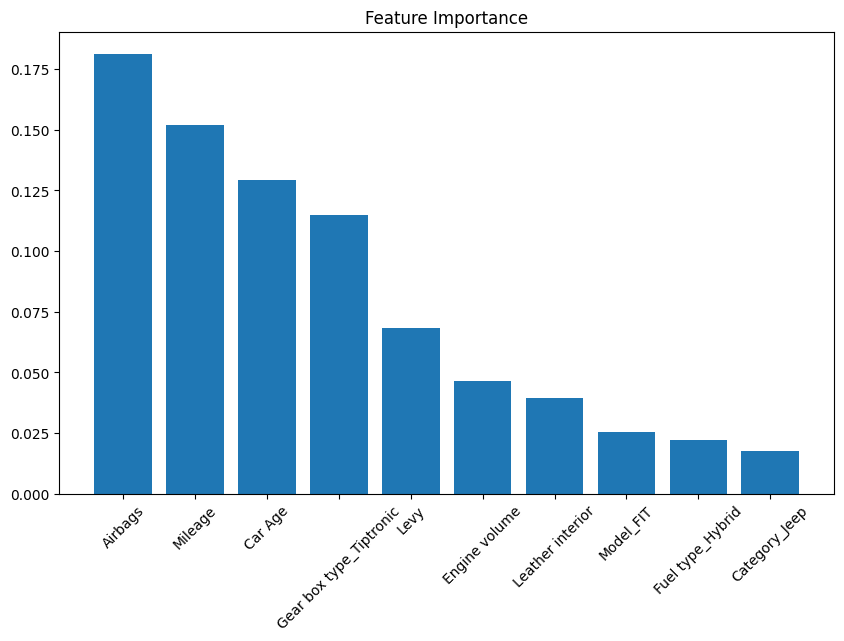

In [21]:
# 10. Feature Importance Plot:
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.bar(range(10), importances[indices][:10])
plt.xticks(range(10), X_train.columns[indices][:10], rotation=45)
plt.show()

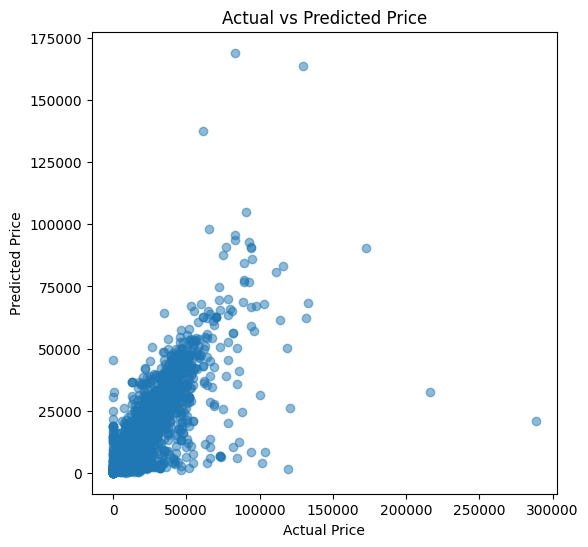

In [22]:
# 11. Actual vs Predicted Plot:

plt.figure(figsize=(6,6))
plt.scatter(y_test_price, y_pred_price, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

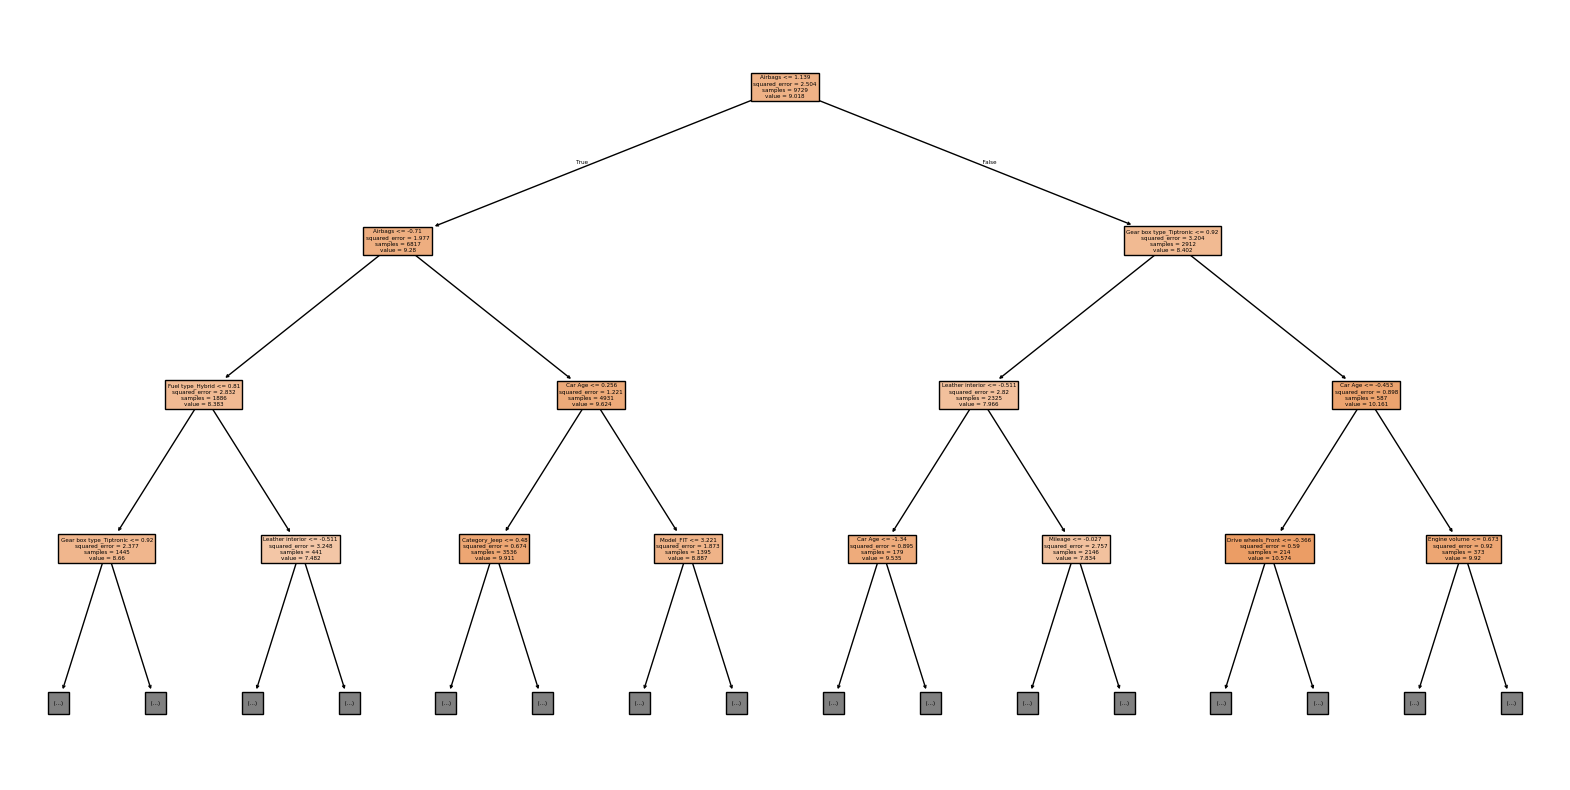

In [23]:
# 12. Single Tree Visualization:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0],
          feature_names=X_train.columns,
          max_depth=3,
          filled=True)
plt.show()

In [24]:
df.to_csv("cleandata.csv",index=False)